# Contextual Bandit

# MCMC-based Thompson Sampling

In [6]:
import numpy as np
import pymc3 as pm

arms = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

class LinearTSAgent(object):
    def __init__(self):
        self.counts = [0 for _ in arms]
        self.wins = [0 for _ in arms]
        self.phis = np.array([[arm[0], arm[1], 1] for arm in arms]).T

    def get_arm(self):
        # 1. Make sure each arm is pulled at least once
        if 0 in self.counts:
            return self.counts.index(0)

        # 2. Estimate the parameters beta
        with pm.Model() as model:
            beta = pm.Normal('beta', mu=0, sigma=10, shape=3)
            linpred = pm.math.dot(beta, self.phis)
            theta = pm.Deterministic(
                'theta', 1 / (1 + pm.math.exp(-linpred))
            )
            obs = pm.Binomial('obs', n=self.counts, p=theta, observed=self.wins)
            trace = pm.sample(2000, chains=1)

        # 3. Take a sample of thetas. Get the arm (context)'s index with the highest theta
        sample = pm.sample_posterior_predictive(trace, samples=1, model=model, var_names=['theta'])
        return np.argmax(sample['theta'])

    def sample(self, arm_index, reward):
        self.counts[arm_index] += 1
        self.wins[arm_index] += reward

In [5]:
class Env(object):
    @staticmethod
    def p(arm):
        x = arm[0] * 0.2 + arm[1] * 0.8 - 4
        p = 1 / (1 + np.exp(-x))
        return p

    @staticmethod
    def react(arm):
        return 1 if np.random.random() < Env.p(arm) else 0

    @staticmethod
    def opt():
        return np.argmax([Env.p(arm) for arm in arms])

In [3]:
np.random.seed(0)
selected_arms = []
earned_rewards = []

n_step = 20
agent = LinearTSAgent()
for step in range(n_step):
    arm_index = agent.get_arm()
    for _ in range(50):
        reward = Env.react(arms[arm_index])
        agent.sample(arm_index, reward)
        selected_arms.append(arm_index)
        earned_rewards.append(reward)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_80411/1692199966.py:30: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(2000, chains=1)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [beta]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 2 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_80411/1692199966.py:30: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(2000, chains=1)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [beta]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 1 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [beta]


...

Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 3 seconds.
The acceptance probability does not match the target. It is 0.8975282222208575, but should be close to 0.8. Try to increase the number of tuning steps.
Only one chain was sampled, this makes it impossible to run some convergence checks


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [beta]


Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 2 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [beta]


Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 2 seconds.
The acceptance probability does not match the target. It is 0.8793619293039919, but should be close to 0.8. Try to increase the number of tuning steps.
Only one chain was sampled, this makes it impossible to run some convergence checks


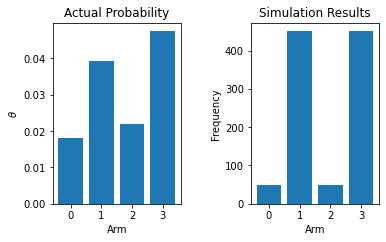

In [4]:
from matplotlib import pyplot as plt
from collections import Counter

arm_count = [row[1] for row in sorted(Counter(selected_arms).items())]
plt.subplot(1, 2, 1)
plt.bar(range(4), [Env.p(arm) for arm in arms], tick_label=range(4))
plt.xlabel('Arm')
plt.ylabel(r'$\theta$')
plt.title('Actual Probability')
plt.subplot(1, 2, 2)
plt.bar(range(4), arm_count, tick_label=range(4))
plt.xlabel('Arm')
plt.ylabel('Frequency')
plt.title('Simulation Results')
plt.tight_layout(pad=3)
plt.show()